#### Đánh giá HYBRID (giá cơ bản × hệ số nhân) vs Hướng 1 (giá cuối trực tiếp)

Nạp `pred_hybrid.parquet` (từ `train/train_hybrid.ipynb`), so sánh 3 thuật toán và 2 phương pháp
(Hướng 1 vs Hybrid) cùng lúc.

In [11]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width", 220)
BLUE, ORANGE = "#0072B2", "#D55E00"

def metrics(y,p):
    y,p=np.asarray(y),np.asarray(p)
    return dict(MAE=mean_absolute_error(y,p), RMSE=mean_squared_error(y,p)**.5,
                R2=r2_score(y,p), MAPE=np.mean(np.abs((y-p)/y))*100)

hybrid = pd.read_parquet("pred_hybrid.parquet")
gia_h1 = pd.read_parquet("pred_gia.parquet")
ALGOS = sorted(hybrid.algo.unique())
thangs = sorted(hybrid.evaluation_month.unique())
print(f"Hybrid: {len(hybrid):,} dong | Huong 1: {len(gia_h1):,} dong | thuat toan: {ALGOS}")

Hybrid: 2,593,080 dong | Huong 1: 2,593,080 dong | thuat toan: ['HistGB', 'LightGBM', 'XGBoost']


**1. Bảng chỉ số — Hướng 1 vs Hybrid, từng thuật toán, tổng gộp & từng test-set nhỏ**

In [12]:
TARGET = "target_shown_price"
rows = []
for algo in ALGOS:
    dh = hybrid[hybrid.algo==algo]; d1 = gia_h1[gia_h1.algo==algo]
    for ten, dcol, dval in [("Huong 1 (truc tiep)", d1, d1["pred"]), ("Hybrid (co ban x he so)", dh, dh["hybrid_pred"])]:
        rows.append({"Thuat toan": algo, "Phuong phap": ten, "Test-set": "TAT CA", "n": len(dcol), **metrics(dcol[TARGET], dval)})
        for th in thangs:
            m = dcol.evaluation_month==th
            rows.append({"Thuat toan": algo, "Phuong phap": ten, "Test-set": th, "n": m.sum(), **metrics(dcol.loc[m, TARGET], dval[m])})
bang = pd.DataFrame(rows).round(2)
print("TONG GOP:"); display(bang[bang["Test-set"]=="TAT CA"].sort_values("MAE"))
print("\nTUNG TEST-SET NHO THEO THANG:"); display(bang[bang["Test-set"]!="TAT CA"])

TONG GOP:


,Thuat toan,Phuong phap,Test-set,n,MAE,RMSE,R2,MAPE
4,HistGB,Hybrid (co ban x he so),TAT CA,864360,18047.97,24533.96,0.73,14.74
12,LightGBM,Hybrid (co ban x he so),TAT CA,864360,18058.76,24548.54,0.73,14.75
20,XGBoost,Hybrid (co ban x he so),TAT CA,864360,18065.92,24568.27,0.73,14.76
16,XGBoost,Huong 1 (truc tiep),TAT CA,864360,18806.72,25602.59,0.71,15.34
8,LightGBM,Huong 1 (truc tiep),TAT CA,864360,18809.03,25607.87,0.71,15.34
0,HistGB,Huong 1 (truc tiep),TAT CA,864360,18834.01,25644.75,0.70,15.36



TUNG TEST-SET NHO THEO THANG:


,Thuat toan,Phuong phap,Test-set,n,MAE,RMSE,R2,MAPE
1,HistGB,Huong 1 (truc tiep),2026-01,315360,18622.75,25327.14,0.71,15.44
2,HistGB,Huong 1 (truc tiep),2026-02,234632,18700.76,25422.74,0.71,15.34
3,HistGB,Huong 1 (truc tiep),2026-03,314368,19145.39,26121.93,0.70,15.29
5,HistGB,Hybrid (co ban x he so),2026-01,315360,17863.11,24331.19,0.73,14.78
6,HistGB,Hybrid (co ban x he so),2026-02,234632,17913.66,24288.23,0.73,14.73
7,HistGB,Hybrid (co ban x he so),2026-03,314368,18333.65,24916.03,0.73,14.72
9,LightGBM,Huong 1 (truc tiep),2026-01,315360,18605.25,25306.00,0.71,15.42
10,LightGBM,Huong 1 (truc tiep),2026-02,234632,18670.77,25372.77,0.71,15.32
11,LightGBM,Huong 1 (truc tiep),2026-03,314368,19116.64,26079.23,0.70,15.27
13,LightGBM,Hybrid (co ban x he so),2026-01,315360,17880.00,24349.61,0.73,14.79


**2. Biểu đồ so sánh MAE: 3 thuật toán × 2 phương pháp**

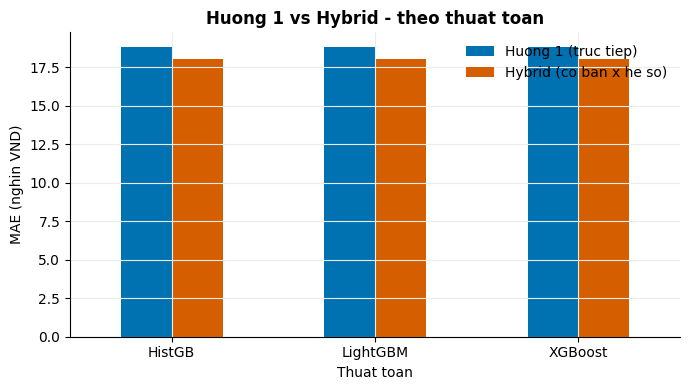

Ket hop tot nhat: HistGB + Hybrid (co ban x he so) (MAE=18,048 VND)


In [13]:
piv = bang[bang["Test-set"]=="TAT CA"].pivot(index="Thuat toan", columns="Phuong phap", values="MAE")/1000
fig, ax = plt.subplots(figsize=(7,4))
piv.plot(kind="bar", ax=ax, color=[BLUE,ORANGE])
ax.set_ylabel("MAE (nghin VND)"); ax.set_title("Huong 1 vs Hybrid - theo thuat toan", fontweight="bold")
ax.tick_params(axis="x", rotation=0); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
best = bang[bang["Test-set"]=="TAT CA"].sort_values("MAE").iloc[0]
print(f"Ket hop tot nhat: {best['Thuat toan']} + {best['Phuong phap']} (MAE={best['MAE']:,.0f} VND)")

**3. Bias trung bình — cả 3 thuật toán (Hướng 1 vs Hybrid)**

Bias trung binh (nghin VND):


,Huong 1,Hybrid
Thuat toan,,
HistGB,-2.9,-2.3
LightGBM,-2.9,-2.3
XGBoost,-2.9,-2.3


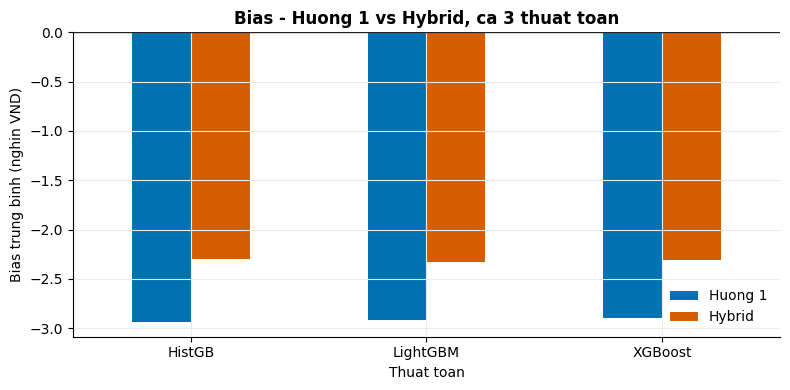

In [14]:
bias_rows = []
for algo in ALGOS:
    dh = hybrid[hybrid.algo==algo]; d1 = gia_h1[gia_h1.algo==algo]
    b1 = (d1.pred - d1[TARGET]).mean()/1000
    b2 = (dh.hybrid_pred - dh[TARGET]).mean()/1000
    bias_rows.append({"Thuat toan": algo, "Huong 1": b1, "Hybrid": b2})
bias_df = pd.DataFrame(bias_rows).set_index("Thuat toan")
print("Bias trung binh (nghin VND):"); display(bias_df.round(1))

fig, ax = plt.subplots(figsize=(8,4))
bias_df.plot(kind="bar", ax=ax, color=[BLUE,ORANGE])
ax.axhline(0,color="#222",lw=1)
ax.set_ylabel("Bias trung binh (nghin VND)"); ax.set_title("Bias - Huong 1 vs Hybrid, ca 3 thuat toan", fontweight="bold")
ax.tick_params(axis="x", rotation=0); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**4. Kết luận**

- Bảng bước 1 cho biết **thuật toán + phương pháp nào MAE thấp nhất** — đó là lựa chọn cuối cho pipeline.
- Nếu Hybrid thắng ở mọi thuật toán → xác nhận việc tách giá cơ bản × hệ số nhân đáng giá.
- Xem thêm bias: hybrid có thể lệch khác Hướng 1 do nhân 2 dự đoán (sai số cộng dồn).

**5. Test case thực tế — chênh lệch thực vs dự đoán (Hướng 1 vs Hybrid)**

Lấy 15 chuyến từ tập test của thuật toán tốt nhất, so **giá thực** với **dự đoán Hướng 1** và
**dự đoán Hybrid**.

In [15]:
if "best_algo" not in dir():
    best_algo = bang[bang["Test-set"]=="TAT CA"].sort_values("MAE").iloc[0]["Thuat toan"]

dh0 = hybrid[hybrid.algo==best_algo].reset_index(drop=True)
d10 = gia_h1[gia_h1.algo==best_algo].reset_index(drop=True)
pos = dh0.sample(15, random_state=7).index

case = pd.DataFrame({
    "Test-set": dh0.loc[pos, "evaluation_month"].values,
    "Gia THUC (k)": (dh0.loc[pos, TARGET]/1000).round(0).astype(int).values,
    "Huong1 DUDOAN (k)": (d10.loc[pos, "pred"]/1000).round(0).astype(int).values,
    "Huong1 Sai so%": (abs(d10.loc[pos, "pred"]-d10.loc[pos, TARGET])/d10.loc[pos, TARGET]*100).round(1).values,
    "Hybrid DUDOAN (k)": (dh0.loc[pos, "hybrid_pred"]/1000).round(0).astype(int).values,
    "Hybrid Sai so%": (abs(dh0.loc[pos, "hybrid_pred"]-dh0.loc[pos, TARGET])/dh0.loc[pos, TARGET]*100).round(1).values,
})
print(f"15 TEST CASE THUC TE ({best_algo}, Huong 1 vs Hybrid):")
display(case.reset_index(drop=True))

15 TEST CASE THUC TE (HistGB, Huong 1 vs Hybrid):


,Test-set,Gia THUC (k),Huong1 DUDOAN (k),Huong1 Sai so%,Hybrid DUDOAN (k),Hybrid Sai so%
0,2026-01,188,194,3.4,206,9.8
1,2026-01,107,90,15.7,95,11.3
2,2026-02,140,106,23.9,110,21.2
3,2026-03,185,176,5.0,189,2.1
4,2026-02,94,92,2.3,92,1.6
5,2026-03,199,123,38.3,127,36.4
6,2026-03,96,115,19.4,115,19.8
7,2026-03,130,99,23.9,100,23.2
8,2026-02,95,80,16.1,84,12.1
9,2026-01,115,99,13.9,106,8.1
